# Głębokie Splotowe Prezeciwstawne Sieci Wytwórcze

In [1]:
import os

# Ustawienie PyTorch jako zaplecza dla biblioteki Keras
os.environ["KERAS_BACKEND"] = "torch"

# PyTorch i tf.keras
#import tensorflow as tf
import torch
import keras
from keras import datasets,callbacks,layers

# Biblioteki pomocnicze
import numpy as np
import matplotlib.pyplot as plt

#print(tf.__version__)
print(keras.__version__)
print(torch.__version__)

# Sprawdzenie dostępności GPU
#print(tf.config.list_physical_devices('GPU'))
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
else:
    if torch.xpu.is_available():
        for i in range(torch.xpu.device_count()):
            print(f"XPU {i}: {torch.xpu.get_device_name(i)}")
    else:
        print("Brak dostępnych GPU lub XPU.")
        print("Używam CPU.")
        
#keras.backend.set_floatx("float16")

3.9.2
2.9.1+xpu
XPU 0: Intel(R) Arc(TM) Graphics


In [2]:
# Create the discriminator
discriminator = keras.Sequential(
    [
        keras.Input(shape=(28, 28, 1)),
        layers.Conv2D(64, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(128, (3, 3), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.GlobalMaxPooling2D(),
        layers.Dense(1),
    ],
    name="discriminator",
)

# Create the generator
latent_dim = 128
generator = keras.Sequential(
    [
        keras.Input(shape=(latent_dim,)),
        # We want to generate 128 coefficients to reshape into a 7x7x128 map
        layers.Dense(7 * 7 * 128),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Reshape((7, 7, 128)),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(1, (7, 7), padding="same", activation="sigmoid"),
    ],
    name="generator",
)

In [5]:
class GAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.d_loss_tracker = keras.metrics.Mean(name="d_loss")
        self.g_loss_tracker = keras.metrics.Mean(name="g_loss")
        self.seed_generator = keras.random.SeedGenerator(1337)
        self.built = True

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, real_images):

        if torch.cuda.is_available():
            device = "cuda"
        else:
            if torch.xpu.is_available():
                device = "xpu"
            else:
                device = "cpu"

        if isinstance(real_images, tuple) or isinstance(real_images, list):
            real_images = real_images[0]
        # Sample random points in the latent space
        batch_size = real_images.shape[0]
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Decode them to fake images
        generated_images = self.generator(random_latent_vectors)

        # Combine them with real images
        real_images = torch.tensor(real_images, device=device)
        combined_images = torch.concat([generated_images, real_images], axis=0)

        # Assemble labels discriminating real from fake images
        labels = torch.concat(
            [
                torch.ones((batch_size, 1), device=device),
                torch.zeros((batch_size, 1), device=device),
            ],
            axis=0,
        )
        # Add random noise to the labels - important trick!
        labels += 0.05 * keras.random.uniform(labels.shape, seed=self.seed_generator)

        # Train the discriminator
        self.zero_grad()
        predictions = self.discriminator(combined_images)
        d_loss = self.loss_fn(labels, predictions)
        d_loss.backward()
        grads = [v.value.grad for v in self.discriminator.trainable_weights]
        with torch.no_grad():
            self.d_optimizer.apply(grads, self.discriminator.trainable_weights)

        # Sample random points in the latent space
        random_latent_vectors = keras.random.normal(
            shape=(batch_size, self.latent_dim), seed=self.seed_generator
        )

        # Assemble labels that say "all real images"
        misleading_labels = torch.zeros((batch_size, 1), device=device)

        # Train the generator (note that we should *not* update the weights
        # of the discriminator)!
        self.zero_grad()
        predictions = self.discriminator(self.generator(random_latent_vectors))
        g_loss = self.loss_fn(misleading_labels, predictions)
        grads = g_loss.backward()
        grads = [v.value.grad for v in self.generator.trainable_weights]
        with torch.no_grad():
            self.g_optimizer.apply(grads, self.generator.trainable_weights)

        # Update metrics and return their value.
        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)
        return {
            "d_loss": self.d_loss_tracker.result(),
            "g_loss": self.g_loss_tracker.result(),
        }

In [6]:
# Prepare the dataset. We use both the training & test MNIST digits.
batch_size = 64
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
all_digits = np.concatenate([x_train, x_test])
all_digits = all_digits.astype("float32") / 255.0
all_digits = np.reshape(all_digits, (-1, 28, 28, 1))

# Create a TensorDataset
dataset = torch.utils.data.TensorDataset(
    torch.from_numpy(all_digits), torch.from_numpy(all_digits)
)
# Create a DataLoader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

gan = GAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)
gan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
)

gan.fit(dataloader, epochs=1)

   1/1094 ━━━━━━━━━━━━━━━━━━━━ 2:13 122ms/step - d_loss: 0.4096 - g_loss: 1.6231

C:\Users\piotr\AppData\Local\Temp\ipykernel_39648\603805934.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  real_images = torch.tensor(real_images, device=device)


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 254s 232ms/step - d_loss: 0.2255 - g_loss: 3.1398


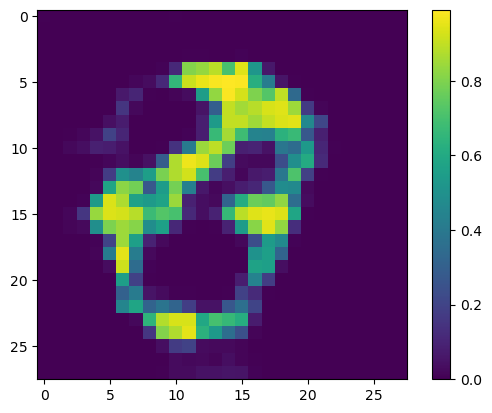

In [ ]:
random_latent_vectors = keras.random.normal(
            shape=(batch_size, gan.latent_dim), seed=gan.seed_generator
        )
generated_images = gan.generator(random_latent_vectors)
generated_images = generated_images.detach()

plt.figure()
plt.imshow(generated_images[0].cpu())
plt.colorbar()
plt.grid(False)
plt.show()

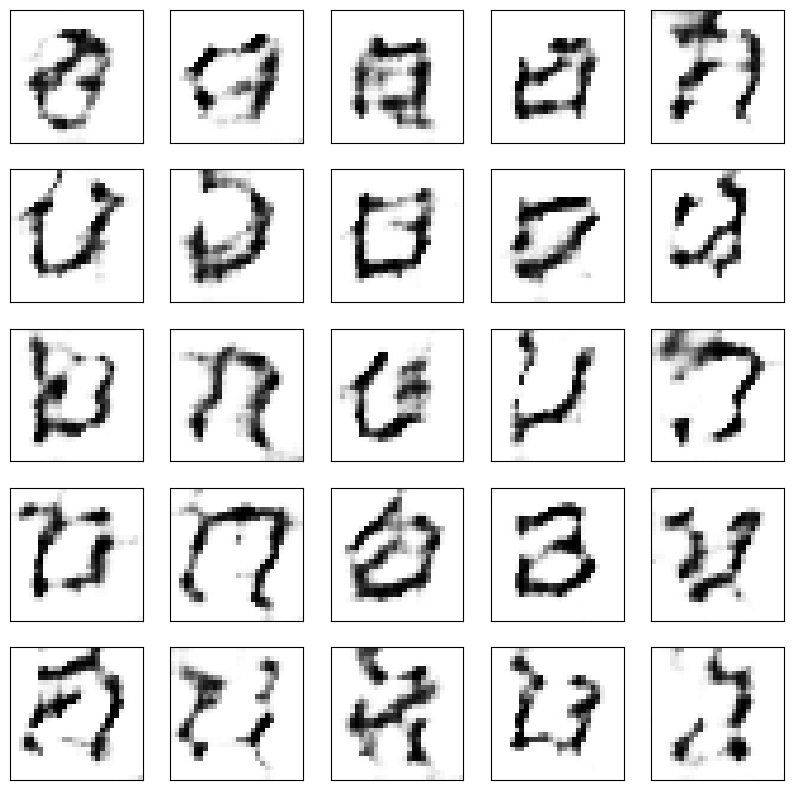

In [40]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(generated_images[i].cpu(), cmap=plt.cm.binary)
plt.show()

## Źródła
 - https://keras.io/guides/custom_train_step_in_torch/#:~:text=Wrapping%20up%3A%20an%20end%2Dto%2Dend%20GAN%20example

## Zadania
1. Co się stanie jak zamienimy funkcję aktywacji LeakyReLU na zwykłe ReLU? Czy efekt będzie różny dla wytwornicy i klasyfikatora? (2 pkt)
2. Zmień zbiór danych na FashionMNIST i dobierz parametry modelu w taki sposób, aby otrzymać czytelne obrazy. (3 pkt.)